# 06 - Active learning

Can the model choose what to annotate next, and does choosing well beat choosing at
random?

## The hypothesis, as originally stated

With 100 or fewer additional windows selected by an acquisition function, the model
reaches F1 >= 0.90, against the roughly 500 that random sampling would need.

**Both halves of that turned out to be wrong**, and the sections below are ordered
so you can see how. The 0.90 target was set without checking it was reachable with
this pool: the best honest macro-F1 is about 0.29. And under a leak-free protocol no
strategy beats random significantly. §B4 is the section that establishes this; §1 to
§11 are the earlier version whose apparent separation came from overlapping windows.

## Protocol

1. Seed set: **20 labelled windows**, stratified by class, varying per seed
2. Base model: the **BiLSTM** with temporal attention from notebook 04
3. **Realistic pool**: about 126 remaining behaviour windows plus **506 background**
   windows. The background windows are distractors: querying one wastes the budget,
   which is the cost a real annotator would pay
4. Strategies: random (baseline), least confidence, margin, entropy, BALD with
   50 MC-dropout passes, coreset (k-centre in attention space), BADGE (gradient
   embeddings plus k-means++), and a combined rank fusion
5. **5 random seeds**, reported as mean and standard deviation
6. 10 rounds of 10 queries
7. Optional early stop when validation F1 plateaus for 3 rounds

## 0. Configuration

In [1]:
import sys
import importlib
from pathlib import Path

# Put the project root on the path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Force a reload of the src modules, so edits apply without restarting the kernel
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith("src."):
        importlib.reload(sys.modules[mod_name])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import h5py
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from src.models.rnn import BehaviorLSTM, BehaviorTCN, BehaviorTransformer, FocalLoss
from src.data.dataset import MouseBehaviorDataset, LabelEncoder
from src.active_learning.query_strategies import (
    LeastConfidenceStrategy,
    MarginSamplingStrategy,
    EntropySamplingStrategy,
    BALDStrategy,
    CoresetStrategy,
    CombinedStrategy,
    HybridCoresetEntropyStrategy,
    HybridScheduleStrategy,
    BADGEStrategy,
    run_al_cycle,
    _default_fit,
    _default_eval,
)
from src.active_learning.oracle import SimulatedOracle, load_pool_from_h5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
print(f"Torch: {torch.__version__}")


Dispositivo: cpu
Torch: 2.11.0+cpu


## 1. Loading the data

In [2]:
H5_PATH = PROJECT_ROOT / "dataset" / "features" / "CalMS21_task1_13638642_features.h5"
CLASS_NAMES = ["approach", "mount", "sniffbody", "sniffface", "sniffgenital"]
encoder = LabelEncoder(classes=CLASS_NAMES, background_label="background")

with h5py.File(H5_PATH, "r") as f:
    print("Claves disponibles:", list(f.keys()))
    X_parts, y_str_parts = [], []
    for mouse_key in f.keys():
        grp = f[mouse_key]
        if "X" in grp and "y" in grp:
            X_m   = grp["X"][:]
            y_raw = grp["y"][:]
            y_str = np.array([
                v.decode() if isinstance(v, bytes) else str(v)
                for v in y_raw
            ])
            X_parts.append(X_m)
            y_str_parts.append(y_str)
            print(f"  {mouse_key}: X={X_m.shape}, classes={np.unique(y_str)}")

    X_all     = np.concatenate(X_parts,     axis=0)
    y_str_all = np.concatenate(y_str_parts, axis=0)

    sniff_site_ratio = None
    if "pool_meta" in f and "sniff_site_ratio" in f["pool_meta"]:
        sniff_site_ratio = f["pool_meta"]["sniff_site_ratio"][:]

y_all = encoder.encode(y_str_all)
labeled_mask  = y_all >= 0
X_labeled     = X_all[labeled_mask]
y_labeled     = y_all[labeled_mask]
X_pool        = X_all[~labeled_mask]   # background windows, label = -1
y_pool_hidden = y_all[~labeled_mask]   # todos son -1

print(f"\nLabelled     : {X_labeled.shape}  |  classes: {np.unique(y_labeled)}")
print(f"Pool (bg)    : {X_pool.shape}")

# ── Split: 30% validation, for statistical stability; it used to be 15% ──
# X_train is the source of both the behavioural pool and the seed.
# The AL loop picks n_initial=20 from X_train as its seed.
X_train, X_val, y_train, y_val = train_test_split(
    X_labeled, y_labeled, test_size=0.30, stratify=y_labeled, random_state=42
)
X_test, y_test = None, None
feature_names = [f"feat_{i}" for i in range(X_train.shape[-1])]

print(f"\nX_train (pool conductual) : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_val   (fijo, nunca tocado) : {X_val.shape}    y_val   : {y_val.shape}")
print(f"X_pool  (background)      : {X_pool.shape}")
print(f"Features: {X_train.shape[-1]}")
print(f"\nTotal AL pool (behavioural + bg): {len(X_train) + len(X_pool)} windows "
      f"(~{len(X_train)} behavioural + {len(X_pool)} background)")


Claves disponibles: ['mouse_1', 'mouse_2', 'split']
  mouse_1: X=(357, 64, 64), clases=['approach' 'background' 'mount' 'sniffbody' 'sniffface' 'sniffgenital']
  mouse_2: X=(357, 64, 64), clases=['background']

Etiquetadas  : (208, 64, 64)  |  clases: [0 1 2 3 4]
Pool (bg)    : (506, 64, 64)

X_train (pool conductual) : (145, 64, 64)  y_train : (145,)
X_val   (fijo, nunca tocado) : (63, 64, 64)    y_val   : (63,)
X_pool  (fondo/bg)        : (506, 64, 64)
Features: 64

Pool AL total (conductual+bg): 651 ventanas (~145 conductual + 506 fondo)


In [3]:
# ── Target classes (CalMS21 task1) ──
CLASS_NAMES = ["approach", "mount", "sniffbody", "sniffface", "sniffgenital"]

# Keep only the classes actually present in the data
unique_classes = np.unique(y_train[y_train >= 0])
print(f"Classes in train: {unique_classes}")

# Class distribution across the labelled set
_, counts = np.unique(y_train[y_train >= 0], return_counts=True)
print("y_train distribution:", dict(zip(unique_classes, counts)))

Clases en train: [0 1 2 3 4]
Distribución y_train: {np.int64(0): np.int64(22), np.int64(1): np.int64(28), np.int64(2): np.int64(51), np.int64(3): np.int64(22), np.int64(4): np.int64(22)}


## 2. Base model

The classifier inside the loop is the BiLSTM with temporal attention from notebook
04, plus a `get_embedding()` method so that the coreset strategy can measure
distances in attention space rather than in raw feature space.

In [4]:
n_features = X_train.shape[-1]
n_classes  = len(CLASS_NAMES)  # the 5 target classes; independent of y_train

print(f"n_features = {n_features}")
print(f"n_classes  = {n_classes}")
print(f"Distinct classes in y_train: {np.unique(y_train)}")


def make_model() -> BehaviorLSTM:
    """Factory: build a fresh M1 model for each AL round.
    BehaviorLSTM already provides get_embedding() for CoresetStrategy.
    """
    return BehaviorLSTM(
        input_size=n_features,
        hidden_size=128,
        num_layers=2,
        n_classes=n_classes,
        dropout=0.3,
        bidirectional=True,
    )


m = make_model()
n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,}")
print(f"d_model (embedding): {m.d_model}")

# Check that get_embedding works
dummy = torch.zeros(2, X_train.shape[1], n_features)
emb = m.get_embedding(dummy)
print(f"Embedding shape: {emb.shape}  (esperado: [2, {m.d_model}])")


n_features = 64
n_classes  = 5
Clases únicas en y_train: [0 1 2 3 4]
Parámetros: 628,741
d_model (embedding): 256
Embedding shape: torch.Size([2, 256])  (esperado: [2, 256])


## 3. Training and evaluation for the loop

Focal loss with per-class weights, as in notebook 04, and a cosine-annealing
schedule.

In [5]:
import torch.utils.data as tud
from src.train import fit as train_fit


def fit_model(
    model: BehaviorLSTM,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_v: np.ndarray,
    y_v: np.ndarray,
    device: torch.device,
    epochs: int = None,
) -> BehaviorLSTM:
    """Train the model with focal loss and return the best checkpoint.

    The epoch count scales with the dataset size, to avoid overfitting in the
    early rounds, where there are few samples, and underfitting in the late ones.
    """
    ds_tr = MouseBehaviorDataset(X_tr, y_tr)
    ds_v  = MouseBehaviorDataset(X_v,  y_v)

    # Per-class weights for the focal loss
    weights = ds_tr.class_weights()
    # Force shape (n_classes,), padding any absent class with a weight of 1
    if len(weights) < n_classes:
        pad = torch.ones(n_classes)
        pad[:len(weights)] = weights
        weights = pad

    loader_tr = tud.DataLoader(ds_tr, batch_size=min(32, len(ds_tr)), shuffle=True, drop_last=False)
    loader_v  = tud.DataLoader(ds_v,  batch_size=64, shuffle=False)

    criterion = FocalLoss(gamma=2.0, weight=weights)

    # Adaptive epochs: more data means more epochs, within [40, 120]
    if epochs is None:
        epochs = max(40, min(120, 20 + len(X_tr) // 2))

    train_fit(
        model,
        loader_tr,
        loader_v,
        epochs=epochs,
        lr=1e-3,
        weight_decay=1e-4,
        patience=15,
        device=device,
        criterion=criterion,
        scheduler_type="cosine",
        augment=True,
        mixup_alpha=0.3,
        verbose=False,
    )
    return model


def eval_model(
    model: BehaviorLSTM,
    X: np.ndarray,
    y: np.ndarray,
    device: torch.device,
) -> float:
    """F1-macro over the given set."""
    model.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, len(X), 256):
            xb = torch.tensor(X[start:start+256], dtype=torch.float32).to(device)
            xb = torch.nan_to_num(xb, nan=0.0)
            preds.extend(model(xb).argmax(dim=-1).cpu().tolist())
    return float(f1_score(y, np.array(preds), average="macro", zero_division=0))


print("Training functions ready.")
print(f"Adaptive epochs: 20 labels -> {max(40, min(120, 20+20//2))}  |  "
      f"120 labels -> {max(40, min(120, 20+120//2))}")


Funciones de entrenamiento listas.
Épocas adaptativas: 20 etiquetas→40  |  120 etiquetas→80


## 4. Experiment configuration

In [6]:
# ── AL loop hyperparameters ──
N_INITIAL         = 20   # labelled windows in the seed, stratified
N_QUERY_PER_ROUND = 10   # queries per round
N_ROUNDS          = 10   # AL rounds
RANDOM_FLOOR      = 0.1  # 10% of queries are random each round, to avoid collapse

# ── Seeds for the repeated runs, which is what gives statistical power ──
SEEDS = [42, 123, 456]

# ── Current class distribution, used by the combined strategy ──
uniq, cnts = np.unique(y_train[y_train >= 0], return_counts=True)
class_counts_arr = np.zeros(len(CLASS_NAMES), dtype=float)
for cls, cnt in zip(uniq, cnts):
    if cls < len(CLASS_NAMES):
        class_counts_arr[int(cls)] = cnt

print("Class distribution (behavioural pool):")
for i, cnt in enumerate(class_counts_arr):
    name = CLASS_NAMES[i] if i < len(CLASS_NAMES) else str(i)
    print(f"  {name:15s}: {int(cnt):3d} windows")

# ── Estrategias a comparar ──
# Note: sniff_site_ratio is only passed when its length matches the current pool;
# otherwise CombinedStrategy ignores the sniff bonus, as the check in query() shows.
strategies = {
    "random":           None,   # Random Sampling (baseline)
    "least_confidence": LeastConfidenceStrategy(),
    "margin":           MarginSamplingStrategy(),
    "entropy":          EntropySamplingStrategy(),
    "bald":             BALDStrategy(n_mc=50),               # 50 pasadas MC (era 30)
    "coreset":          CoresetStrategy(metric="cosine"),
    "badge":            BADGEStrategy(),                     # nuevo
    "hybrid":           HybridCoresetEntropyStrategy(alpha=0.5, metric="cosine"),
    "combined":         CombinedStrategy(
                            class_counts=class_counts_arr,
                            sniff_site_ratio=sniff_site_ratio,
                            sniff_threshold=0.3,
                            n_mc=10,
                        ),
    "hybrid_schedule":  HybridScheduleStrategy(switch_round=5, n_mc=50),  # era n_mc=30
}

print(f"\nEstrategias: {list(strategies.keys())}")
print(f"Seeds       : {SEEDS}")
print(f"Initial seed  : {N_INITIAL} | Rounds: {N_ROUNDS} | Queries/round: {N_QUERY_PER_ROUND}")
print(f"Random floor  : {RANDOM_FLOOR*100:.0f}% random each round")
print(f"Maximum queries per cycle: {N_ROUNDS * N_QUERY_PER_ROUND}")
print(f"Total AL cycles : {len(strategies)} strategies x {len(SEEDS)} seeds = "
      f"{len(strategies) * len(SEEDS)} ejecuciones")


Distribución de clases (pool conductual):
  approach       :  22 ventanas
  mount          :  28 ventanas
  sniffbody      :  51 ventanas
  sniffface      :  22 ventanas
  sniffgenital   :  22 ventanas

Estrategias: ['random', 'least_confidence', 'margin', 'entropy', 'bald', 'coreset', 'badge', 'hybrid', 'combined', 'hybrid_schedule']
Semillas    : [42, 123, 456]
Semilla inicial : 20 | Rondas: 10 | Consultas/ronda: 10
Random floor    : 10% aleatorio por ronda
Total consultas máximo por ciclo: 100
Total ciclos AL : 10 estrategias × 3 semillas = 30 ejecuciones


## 5. The active learning loop

In [7]:
import copy

# ── Random sampling: the model-free baseline ──
class RandomStrategy:
    name = "random"
    def query(self, model, pool_X, n_query, device=None, **kwargs):
        rng = np.random.default_rng()
        return rng.choice(len(pool_X), size=min(n_query, len(pool_X)), replace=False)

strategies["random"] = RandomStrategy()

# ── A realistic AL pool ──
# X_train holds the behaviourally labelled windows, 70% of X_labeled.
# X_pool holds the background windows, label = -1.
# The AL loop takes n_initial=20 of X_train as its seed, via random_state; what
# remains of X_train plus all of X_pool forms the queryable pool.
# Querying a background window counts as a "wasted query".

print("Composition of the AL pool:")
print(f"  X_train (behavioural, includes the seed source): {len(X_train):4d} windows")
print(f"  X_pool  (background, the distractors)          : {len(X_pool):4d} windows")
print(f"  Total pool (after the seed is drawn)           : ~{len(X_train) - N_INITIAL + len(X_pool):4d} windows")
print(f"  X_val   (fixed validation set)                 : {len(X_val):4d} windows")
print()

# ── Main loop: 3 seeds x N strategies ──
# all_histories[strategy_name] = [hist_seed0, hist_seed1, ..., hist_seed2]
all_histories = {name: [] for name in strategies}

for seed_i, seed_val in enumerate(SEEDS):
    print(f"\n{'#'*65}")
    print(f"# SEED {seed_i+1}/{len(SEEDS)}  (random_state={seed_val})")
    print(f"{'#'*65}")

    for strategy_name, strategy in strategies.items():
        print(f"\n{'='*55}")
        print(f"Strategy: {strategy_name.upper()}  |  seed={seed_val}")
        print(f"{'='*55}")

        # Reset the internal state of the phase-aware strategies
        if hasattr(strategy, "reset"):
            strategy.reset()

        history = run_al_cycle(
            strategy=strategy,
            model_factory=make_model,
            train_X=X_train,            # seed source, the behavioural windows
            train_y=y_train,
            pool_X=X_pool,              # background pool, the distractors
            pool_y=y_pool_hidden,       # todos -1
            val_X=X_val,                # fixed validation set
            val_y=y_val,
            n_initial=N_INITIAL,
            n_query_per_round=N_QUERY_PER_ROUND,
            n_rounds=N_ROUNDS,
            device=DEVICE,
            fit_fn=fit_model,
            eval_fn=eval_model,
            random_floor=RANDOM_FLOOR,
            random_state=seed_val,
            add_train_remainder_to_pool=True,   # leftover behavioural windows join the pool
            verbose=True,
        )
        all_histories[strategy_name].append(history)

print("\n✅ AL cycle complete.")
print(f"Results: {len(all_histories)} strategies x {len(SEEDS)} seeds")


Composición del pool AL:
  X_train (conductual, incluye fuente de semilla):  145 ventanas
  X_pool  (fondo/background, distractores)       :  506 ventanas
  Pool total (tras selección de semilla)         : ~ 631 ventanas
  X_val   (validación fija)                      :   63 ventanas


#################################################################
# SEMILLA 1/3  (random_state=42)
#################################################################

Estrategia: RANDOM  |  semilla=42
[AL random] ronda  0 | etiquetadas= 20 | train_f1=1.0000 | val_f1=0.5344
[AL random] ronda  1 | etiquetadas= 24 | train_f1=0.8124 | val_f1=0.5496
[AL random] ronda  2 | etiquetadas= 26 | train_f1=0.9556 | val_f1=0.5750
[AL random] ronda  3 | etiquetadas= 28 | train_f1=0.9596 | val_f1=0.6027
[AL random] ronda  4 | etiquetadas= 32 | train_f1=1.0000 | val_f1=0.5830
[AL random] ronda  5 | etiquetadas= 33 | train_f1=0.9644 | val_f1=0.6184
[AL random] ronda  6 | etiquetadas= 34 | train_f1=1.0000 | val_f1=0.5605
[

## 6. Learning curves, mean and standard deviation over 5 seeds

Each curve is the mean validation macro-F1 over 5 independent seeds. The shaded band
is one standard deviation: wide bands mean the result depends on which windows
happened to be in the seed set, narrow bands mean the strategy is robust to it.

**On the x axis:** it counts *usefully* labelled windows, excluding queries spent on
background. Random can therefore advance more slowly per query, which is the effect
being measured.

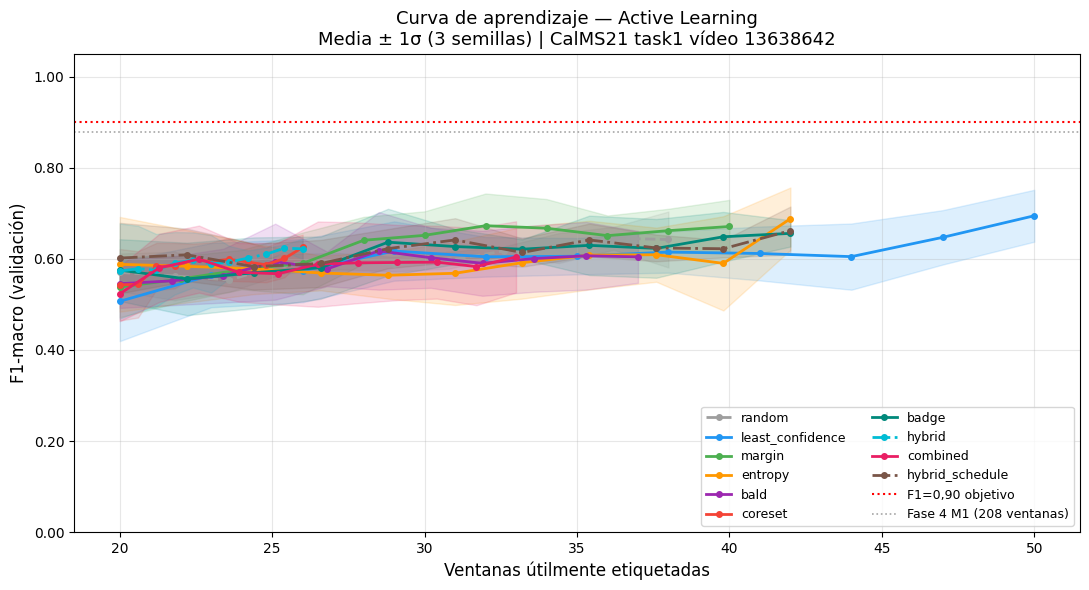

Figura guardada en results/phase5_al_learning_curves.png


In [8]:
def _aggregate_histories(histories_list):
    """Mean and std of val_f1 against n_labeled, across several seeds.

    Interpolates onto a common n_labeled grid so that curves from different
    seeds are comparable; dynamic stopping leaves them slightly different
    lengths otherwise.
    """
    # Determine the common n_labeled range
    min_n = max(h["n_labeled"][0]  for h in histories_list)
    max_n = min(h["n_labeled"][-1] for h in histories_list)
    grid  = np.linspace(min_n, max_n, num=N_ROUNDS + 1)

    all_f1 = []
    for h in histories_list:
        # Linear interpolation onto the common grid
        f1_interp = np.interp(grid, h["n_labeled"], h["val_f1"])
        all_f1.append(f1_interp)
    all_f1 = np.array(all_f1)  # (n_seeds, n_points)
    return grid, all_f1.mean(axis=0), all_f1.std(axis=0)


color_map = {
    "random":           "#9E9E9E",
    "least_confidence": "#2196F3",
    "margin":           "#4CAF50",
    "entropy":          "#FF9800",
    "bald":             "#9C27B0",
    "coreset":          "#F44336",
    "badge":            "#00897B",
    "hybrid":           "#00BCD4",
    "combined":         "#E91E63",
    "hybrid_schedule":  "#795548",
}
line_map = {
    "random":           "--",
    "least_confidence": "-",
    "margin":           "-",
    "entropy":          "-",
    "bald":             "-",
    "coreset":          "-",
    "badge":            "-",
    "hybrid":           "-.",
    "combined":         "-",
    "hybrid_schedule":  "-.",
}

fig, ax = plt.subplots(figsize=(11, 6))

for name, histories in all_histories.items():
    if not histories:
        continue
    grid, mean_f1, std_f1 = _aggregate_histories(histories)
    color = color_map.get(name, "black")
    ls    = line_map.get(name, "-")

    ax.plot(grid, mean_f1, label=name, color=color, linestyle=ls,
            marker="o", markersize=4, linewidth=2)
    ax.fill_between(grid, mean_f1 - std_f1, mean_f1 + std_f1,
                    alpha=0.15, color=color)

# Reference lines
ax.axhline(0.90,  color="red",  linestyle=":", linewidth=1.5, label="F1=0,90 objetivo")
ax.axhline(0.878, color="gray", linestyle=":", linewidth=1.2, alpha=0.7,
           label="Classical M1 baseline (208 windows)")

ax.set_xlabel("Usefully labelled windows", fontsize=12)
ax.set_ylabel("F1-macro (validation)", fontsize=12)
ax.set_title(
    "Active-learning curve\n"
    f"Mean ± 1 sd ({len(SEEDS)} seeds) | CalMS21 task1, video 13638642",
    fontsize=13,
)
ax.legend(fontsize=9, loc="lower right", ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.0, 1.05)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}"))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "phase5_al_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en results/phase5_al_learning_curves.png")


## 6b. Train against validation F1, first seed

A large train-validation gap means the model is memorising the labelled set, which
is expected in the first rounds when that set is tiny. Worth checking before reading
anything into the curves above.

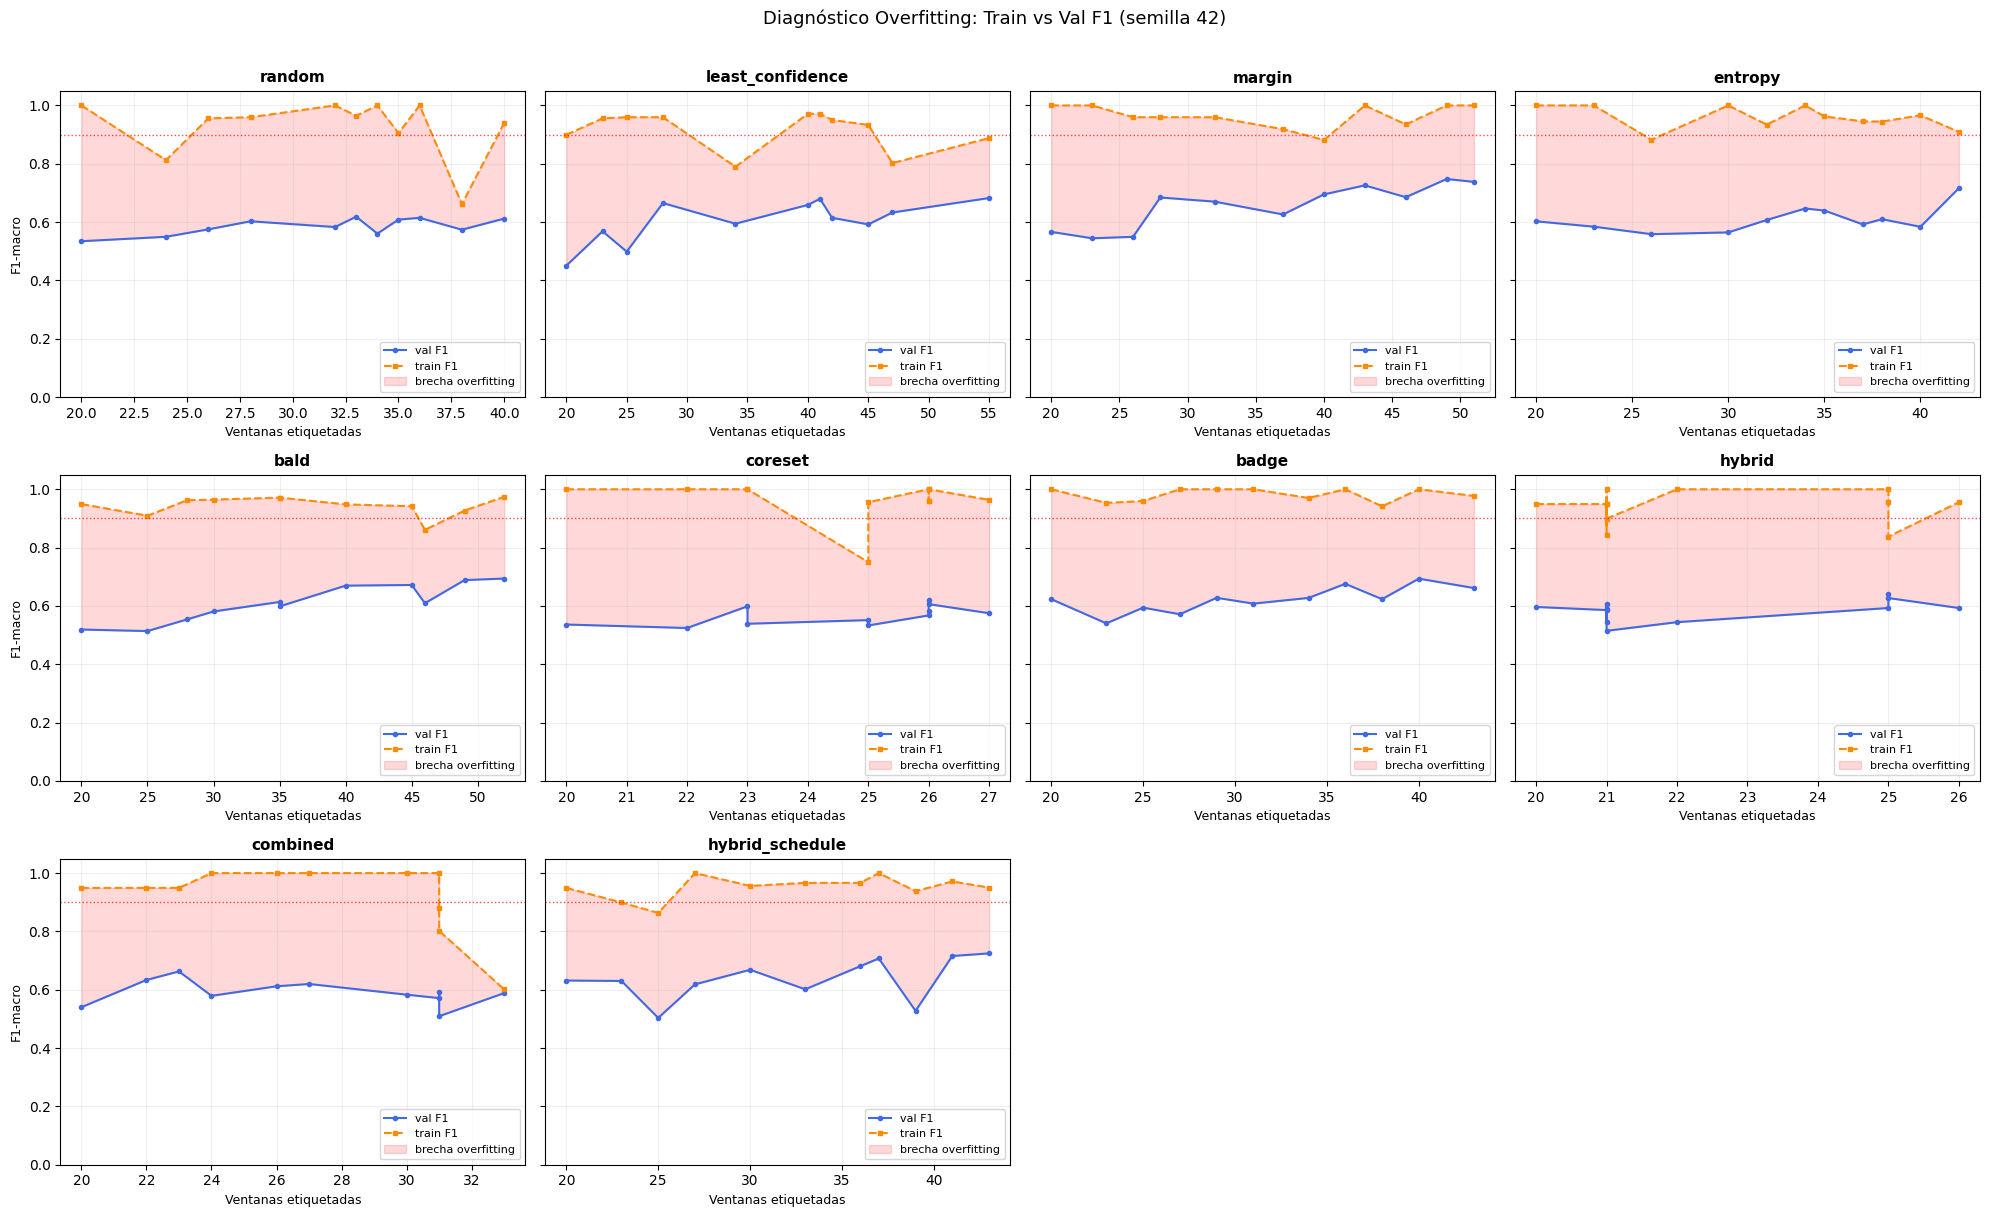

Figura guardada en results/phase5_al_train_val_f1.png


In [9]:
# Use the first seed as representative for the overfitting diagnostic
results_seed0 = {name: hists[0] for name, hists in all_histories.items() if hists}

n_strats = len(results_seed0)
ncols = min(4, n_strats)
nrows = (n_strats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes_flat = np.array(axes).flatten() if n_strats > 1 else [axes]

for ax_i, (name, hist) in enumerate(results_seed0.items()):
    ax = axes_flat[ax_i]
    n_lab = hist["n_labeled"]
    train_f1_vals = hist.get("train_f1", [None] * len(n_lab))
    val_f1_vals   = hist["val_f1"]

    ax.plot(n_lab, val_f1_vals,   label="val F1",   color="royalblue",  marker="o", markersize=3)
    if train_f1_vals[0] is not None:
        ax.plot(n_lab, train_f1_vals, label="train F1", color="darkorange", marker="s", markersize=3, linestyle="--")
        ax.fill_between(n_lab, val_f1_vals, train_f1_vals,
                        where=[t >= v for t, v in zip(train_f1_vals, val_f1_vals)],
                        alpha=0.15, color="red", label="brecha overfitting")

    ax.axhline(0.90, color="red", linestyle=":", linewidth=1.0, alpha=0.7)
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Labelled windows", fontsize=9)
    if ax_i % ncols == 0:
        ax.set_ylabel("F1-macro", fontsize=9)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.2)
    ax.set_ylim(0.0, 1.05)

for ax_j in range(n_strats, len(axes_flat)):
    axes_flat[ax_j].set_visible(False)

fig.suptitle("Overfitting diagnostic: train vs val F1 (seed 42)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "phase5_al_train_val_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en results/phase5_al_train_val_f1.png")


## 7. Labelling efficiency

- **AULC**: area under the F1 against useful-labels curve, which summarises the
  whole trajectory rather than its endpoint
- **F1_final**: macro-F1 at the last round
- **N_for_F1_90**: how many useful labels each strategy needs to reach F1 >= 0.90
- **Wasted queries**: the fraction that landed on background windows

Mean and standard deviation over 5 seeds.

In [10]:
_trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))

total_queries_per_cycle = N_ROUNDS * N_QUERY_PER_ROUND

summary_rows = []

for name, histories in all_histories.items():
    if not histories:
        continue

    aulc_list, f1_final_list, n90_list, waste_pct_list = [], [], [], []

    for h in histories:
        n_lab = np.array(h["n_labeled"])
        f1s   = np.array(h["val_f1"])

        # AULC normalizado
        max_labeled = n_lab.max()
        aulc = float(_trapz(f1s, n_lab)) / max(max_labeled, 1)
        aulc_list.append(aulc)

        # F1 final
        f1_final_list.append(float(f1s[-1]))

        # Labels needed to reach 90% of the run's OWN best F1. This relative target
        # is always defined, whereas an absolute 0.90 was unreachable on this task
        # and left the column entirely NaN.
        _tgt = 0.90 * float(f1s.max())
        above_90 = n_lab[f1s >= _tgt]
        n90_list.append(int(above_90.min()) if len(above_90) > 0 else int(n_lab.max()))

        # Wasted queries, meaning background windows that were queried
        total_wasted = sum(h.get("wasted_queries", []))
        waste_pct_list.append(100.0 * total_wasted / max(total_queries_per_cycle, 1))

    # Statistics across seeds
    mean_aulc  = np.mean(aulc_list)
    std_aulc   = np.std(aulc_list)
    mean_f1    = np.mean(f1_final_list)
    std_f1     = np.std(f1_final_list)
    n90_valid  = [v for v in n90_list if v is not None]
    n90_str    = f"{int(np.median(n90_valid))}" if n90_valid else "not reached"
    mean_waste = np.mean(waste_pct_list)
    std_waste  = np.std(waste_pct_list)

    summary_rows.append({
        "Strategy":         name,
        "AULC (μ±σ)":       f"{mean_aulc:.4f} ± {std_aulc:.4f}",
        "F1_final (μ±σ)":   f"{mean_f1:.4f} ± {std_f1:.4f}",
        "N_labels_90%best":  n90_str,
        "Wasted %":         f"{mean_waste:.1f} ± {std_waste:.1f}",
        # Numeric values, used for sorting
        "_aulc_mean": mean_aulc,
    })

df_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("_aulc_mean", ascending=False)
    .drop(columns=["_aulc_mean"])
    .reset_index(drop=True)
)
display(df_summary)

# Save a detailed version, with the per-seed values
detail_rows = []
for name, histories in all_histories.items():
    for s_i, (seed_val, h) in enumerate(zip(SEEDS, histories)):
        n_lab = np.array(h["n_labeled"])
        f1s   = np.array(h["val_f1"])
        aulc  = float(_trapz(f1s, n_lab)) / max(n_lab.max(), 1)
        above = n_lab[f1s >= 0.90 * float(f1s.max())]  # 90% of this run's best F1
        wasted = sum(h.get("wasted_queries", []))
        detail_rows.append({
            "strategy":    name,
            "seed":        seed_val,
            "aulc":        round(aulc, 4),
            "f1_final":    round(float(f1s[-1]), 4),
            "n_labels_to_90pct_best": int(above.min()) if len(above) else int(n_lab.max()),
            "wasted_queries": wasted,
            "waste_pct":   round(100.0 * wasted / max(total_queries_per_cycle, 1), 1),
        })

df_detail = pd.DataFrame(detail_rows)
df_detail.to_csv(PROJECT_ROOT / "results" / "phase5_al_summary.csv", index=False)
df_summary.to_csv(PROJECT_ROOT / "results" / "phase5_al_summary_agg.csv", index=False)
print("Tablas guardadas en results/phase5_al_summary.csv y phase5_al_summary_agg.csv")


,Estrategia,AULC (μ±σ),F1_final (μ±σ),N_labels_90%best,Desperdiciadas %
0,margin,0.3720 ± 0.0216,0.7002 ± 0.0460,33,72.0 ± 5.7
1,least_confidence,0.3706 ± 0.0368,0.7048 ± 0.0507,43,68.3 ± 2.4
2,bald,0.3453 ± 0.0260,0.6850 ± 0.0180,40,72.7 ± 7.3
3,entropy,0.3434 ± 0.0465,0.6821 ± 0.0302,34,73.0 ± 3.7
4,hybrid_schedule,0.3320 ± 0.0257,0.6707 ± 0.0567,30,77.0 ± 0.8
5,badge,0.3303 ± 0.0203,0.6644 ± 0.0118,29,76.7 ± 1.2
6,random,0.3086 ± 0.0208,0.6844 ± 0.0513,26,78.7 ± 3.4
7,combined,0.2771 ± 0.0310,0.6099 ± 0.0225,22,81.3 ± 5.4
8,coreset,0.1557 ± 0.0141,0.6023 ± 0.0441,21,92.7 ± 1.2
9,hybrid,0.1377 ± 0.0102,0.6218 ± 0.0223,20,94.0 ± 0.0


Tablas guardadas en results/phase5_al_summary.csv y phase5_al_summary_agg.csv


## 8. Query distribution by class

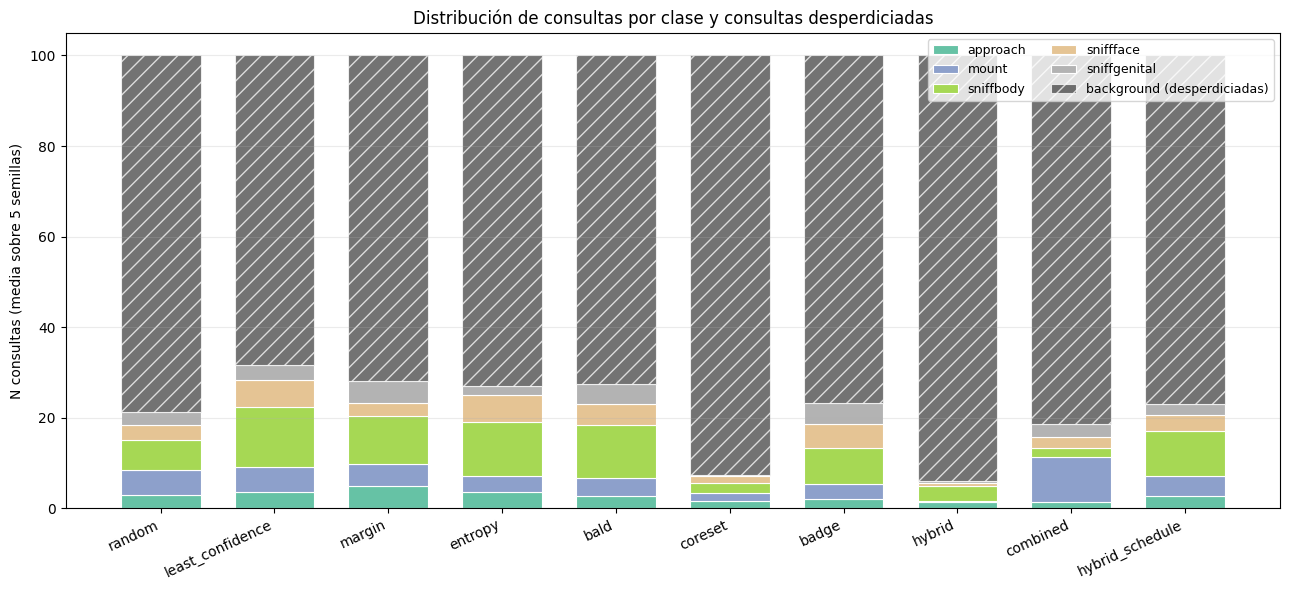

Figura guardada en results/phase5_al_query_distribution.png


In [11]:
# Distribution of queried classes per strategy, averaged over seeds.
# Wasted queries (background, label=-1) are included too.

NUM_CLASSES = len(CLASS_NAMES)

def _rebuild_full_pool_labels(train_y, pool_y, n_initial, random_state):
    """Rebuild the initial pool labels in the same order run_al_cycle used."""
    rng = np.random.default_rng(random_state)
    n_seed = min(n_initial, len(train_y))
    classes = np.unique(train_y)
    per_class = max(1, n_seed // len(classes))

    seed_idx_list = []
    for c in classes:
        c_idx = np.where(train_y == c)[0]
        chosen = rng.choice(c_idx, size=min(per_class, len(c_idx)), replace=False)
        seed_idx_list.extend(chosen.tolist())

    remaining_budget = n_seed - len(seed_idx_list)
    if remaining_budget > 0:
        chosen_set = set(seed_idx_list)
        available = [i for i in range(len(train_y)) if i not in chosen_set]
        if available:
            extra = rng.choice(available, size=min(remaining_budget, len(available)), replace=False)
            seed_idx_list.extend(extra.tolist())

    seed_idx = np.array(seed_idx_list[:n_seed])
    not_seed = np.setdiff1d(np.arange(len(train_y)), seed_idx)
    full_pool_y = np.concatenate([train_y[not_seed], pool_y], axis=0)
    return full_pool_y


strategy_names = [name for name, h in all_histories.items() if h]
class_means = {name: [] for name in strategy_names}
waste_means = {name: [] for name in strategy_names}

for name in strategy_names:
    histories = all_histories[name]
    per_seed_class_counts = []
    per_seed_waste = []

    for seed_val, hist in zip(SEEDS, histories):
        full_pool_y_seed = _rebuild_full_pool_labels(y_train, y_pool_hidden, N_INITIAL, seed_val)

        queried_labels_all = []
        queried_idx_rounds = hist.get("queried_idx", [])
        queried_lbl_rounds = hist.get("queried_labels", None)

        for r_i, idx_round in enumerate(queried_idx_rounds):
            idx_arr = np.asarray(idx_round, dtype=int)

            if queried_lbl_rounds is not None and r_i < len(queried_lbl_rounds):
                lbl_arr = np.asarray(queried_lbl_rounds[r_i], dtype=int)
            else:
                lbl_arr = full_pool_y_seed[idx_arr]

            queried_labels_all.extend(lbl_arr.tolist())

        if len(queried_labels_all) == 0:
            per_seed_class_counts.append(np.zeros(NUM_CLASSES, dtype=float))
            per_seed_waste.append(0.0)
            continue

        q = np.asarray(queried_labels_all, dtype=int)
        useful = q[q >= 0]
        counts = np.bincount(useful, minlength=NUM_CLASSES).astype(float)
        waste = float((q < 0).sum())

        per_seed_class_counts.append(counts)
        per_seed_waste.append(waste)

    class_means[name] = np.mean(np.vstack(per_seed_class_counts), axis=0)
    waste_means[name] = float(np.mean(per_seed_waste))

# Plot: bars stacked per class, plus the wasted-query segment
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(strategy_names))
width = 0.7

bottom = np.zeros(len(strategy_names), dtype=float)
class_colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))

for c in range(NUM_CLASSES):
    vals = np.array([class_means[name][c] for name in strategy_names])
    ax.bar(
        x,
        vals,
        width,
        bottom=bottom,
        label=f"{CLASS_NAMES[c]}",
        color=class_colors[c],
        edgecolor="white",
        linewidth=0.8,
    )
    bottom += vals

waste_vals = np.array([waste_means[name] for name in strategy_names])
ax.bar(
    x,
    waste_vals,
    width,
    bottom=bottom,
    label="background (desperdiciadas)",
    color="#444444",
    alpha=0.75,
    hatch="//",
    edgecolor="white",
    linewidth=0.8,
)

ax.set_xticks(x)
ax.set_xticklabels(strategy_names, rotation=25, ha="right")
ax.set_ylabel("Number of queries (mean over 5 seeds)")
ax.set_title("Queries per class, and wasted queries")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "phase5_al_query_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en results/phase5_al_query_distribution.png")


## 9. The sniff-site bonus and `sniffface`

`sniffface` is among the hardest classes, so if the combined strategy's sniff-site
bonus does anything, it should show up here before it shows up in the average.

In [12]:
# Compare per-class F1 of each strategy's final model, on the first seed
from sklearn.metrics import classification_report

final_models = {}
hist_seed0 = {name: hists[0] for name, hists in all_histories.items() if hists}

# Rebuild the seed and initial pool (seed 42) to map the global queried_idx.
def _rebuild_seed_and_pool(train_X, train_y, pool_X, pool_y, n_initial, random_state):
    rng = np.random.default_rng(random_state)
    n_seed = min(n_initial, len(train_X))
    classes = np.unique(train_y)
    per_class = max(1, n_seed // len(classes))
    seed_idx_list = []

    for c in classes:
        c_idx = np.where(train_y == c)[0]
        chosen = rng.choice(c_idx, size=min(per_class, len(c_idx)), replace=False)
        seed_idx_list.extend(chosen.tolist())

    remaining_budget = n_seed - len(seed_idx_list)
    if remaining_budget > 0:
        chosen_set = set(seed_idx_list)
        available = [i for i in range(len(train_X)) if i not in chosen_set]
        if available:
            extra = rng.choice(available, size=min(remaining_budget, len(available)), replace=False)
            seed_idx_list.extend(extra.tolist())

    seed_idx = np.array(seed_idx_list[:n_seed])
    X_seed_r = train_X[seed_idx]
    y_seed_r = train_y[seed_idx]
    not_seed = np.setdiff1d(np.arange(len(train_X)), seed_idx)
    full_pool_X = np.concatenate([train_X[not_seed], pool_X], axis=0)
    full_pool_y = np.concatenate([train_y[not_seed], pool_y], axis=0)
    return X_seed_r, y_seed_r, full_pool_X, full_pool_y


X_seed_r0, y_seed_r0, full_pool_X_r0, full_pool_y_r0 = _rebuild_seed_and_pool(
    X_train, y_train, X_pool, y_pool_hidden, N_INITIAL, SEEDS[0]
)

for strategy_name, hist in hist_seed0.items():
    # Rebuild that run's final labelled set
    X_labeled_final = X_seed_r0.copy()
    y_labeled_final = y_seed_r0.copy()

    queried_idx_rounds = hist.get("queried_idx", [])
    queried_lbl_rounds = hist.get("queried_labels", None)

    for r_i, idx_round in enumerate(queried_idx_rounds):
        idx_arr = np.asarray(idx_round, dtype=int)

        if queried_lbl_rounds is not None and r_i < len(queried_lbl_rounds):
            lbl_arr = np.asarray(queried_lbl_rounds[r_i], dtype=int)
        else:
            lbl_arr = full_pool_y_r0[idx_arr]

        useful_mask = lbl_arr >= 0
        useful_idx = idx_arr[useful_mask]

        if len(useful_idx) > 0:
            X_labeled_final = np.concatenate([X_labeled_final, full_pool_X_r0[useful_idx]], axis=0)
            y_labeled_final = np.concatenate([y_labeled_final, lbl_arr[useful_mask]], axis=0)

    # Train the final model
    model_final = make_model()
    model_final = fit_model(model_final, X_labeled_final, y_labeled_final,
                            X_val, y_val, DEVICE, epochs=100)
    final_models[strategy_name] = model_final

# Per-class F1 on validation
per_class_f1 = {}
for strategy_name, model in final_models.items():
    model.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, len(X_val), 256):
            xb = torch.tensor(X_val[start:start+256], dtype=torch.float32).to(DEVICE)
            xb = torch.nan_to_num(xb, nan=0.0)
            preds.extend(model(xb).argmax(dim=-1).cpu().tolist())

    report = classification_report(y_val, np.array(preds), output_dict=True, zero_division=0)
    per_class_f1[strategy_name] = {
        int(k): v["f1-score"]
        for k, v in report.items()
        if k.isdigit()
    }

print("Per-class F1 (validation) - final models, seed 42:")
df_perclass = pd.DataFrame(per_class_f1).T
df_perclass.columns = [
    CLASS_NAMES[int(c)] if int(c) < len(CLASS_NAMES) else str(c)
    for c in df_perclass.columns
]
display(df_perclass.round(3))


F1 por clase (validación) — modelos finales (semilla 42):


,approach,mount,sniffbody,sniffface,sniffgenital
random,0.588,0.741,0.634,0.417,0.706
least_confidence,0.762,0.696,0.692,0.462,0.824
margin,0.900,0.774,0.667,0.667,0.857
entropy,0.700,0.714,0.513,0.429,0.720
bald,0.720,0.696,0.682,0.750,0.889
coreset,0.286,0.800,0.286,0.348,0.818
badge,0.737,0.828,0.500,0.500,0.818
hybrid,0.500,0.769,0.474,0.455,0.750
combined,0.556,0.615,0.387,0.353,0.588
hybrid_schedule,0.667,0.786,0.667,0.471,0.741


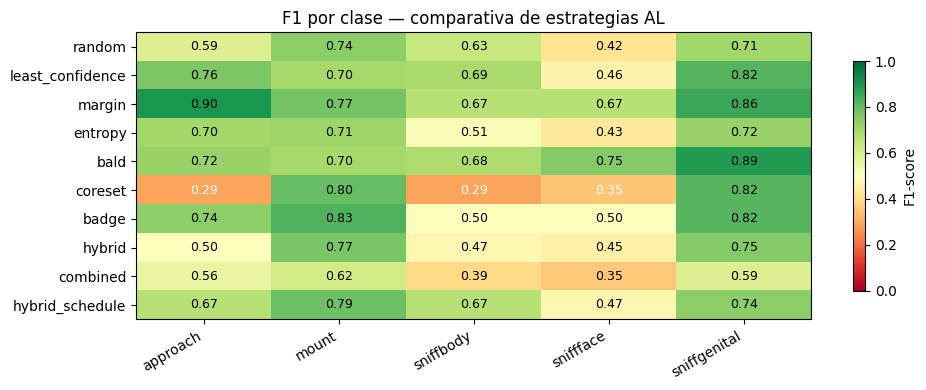

In [13]:
# Per-class F1 heatmap
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(df_perclass.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(len(df_perclass.columns)))
ax.set_xticklabels(df_perclass.columns, rotation=30, ha="right", fontsize=10)
ax.set_yticks(range(len(df_perclass.index)))
ax.set_yticklabels(df_perclass.index, fontsize=10)

for i in range(len(df_perclass.index)):
    for j in range(len(df_perclass.columns)):
        val = df_perclass.values[i, j]
        text_color = "black" if 0.35 < val < 0.75 else "white" if val <= 0.35 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=text_color)

plt.colorbar(im, ax=ax, shrink=0.8, label="F1-score")
ax.set_title("Per-class F1 - comparison of AL strategies", fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "phase5_al_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Phase summary

In [14]:
print("=" * 70)
print("ACTIVE LEARNING SUMMARY (v2, improved methodology)")
print("=" * 70)
print(f"\nModelo base: BiLSTM M1 (BehaviorLSTM + TemporalAttention)")
print(f"AL pool    : {len(X_train) - N_INITIAL + len(X_pool)} windows max per seed "
      f"(~{len(X_train)} conductual + {len(X_pool)} background/distractores)")
print(f"Val        : {len(X_val)} windows (30% of X_labeled, fixed)")
print(f"Seeds      : {SEEDS}")
print(f"Rounds     : {N_ROUNDS} x {N_QUERY_PER_ROUND} queries/round")
print()
print(f"{'Strategy':20s} {'AULC (μ±σ)':22s} {'F1-final (μ±σ)':22s} {'Wasted %':12s} {'N F1≥0.90':10s}")
print("-" * 90)
for _, row in df_summary.iterrows():
    print(f"{row['Strategy']:20s} {row['AULC (μ±σ)']:22s} {row['F1_final (μ±σ)']:22s} "
          f"{row['Wasted %']:12s} {str(row['N_labels_90%best']):10s}")

best = df_summary.iloc[0]
print(f"\nBest strategy (AULC): {best['Strategy']}  AULC={best['AULC (μ±σ)']}")
print()
print("Files written:")
print("  results/phase5_al_learning_curves.png")
print("  results/phase5_al_query_distribution.png")
print("  results/phase5_al_f1_heatmap.png")
print("  results/phase5_al_summary.csv        (per-seed detail)")
print("  results/phase5_al_summary_agg.csv    (media ± std agregado)")


RESUMEN FASE 5 — ACTIVE LEARNING (v2, metodología mejorada)

Modelo base: BiLSTM M1 (BehaviorLSTM + TemporalAttention)
Pool AL    : 631 ventanas máx. por semilla (~145 conductual + 506 background/distractores)
Val        : 63 ventanas (30 % de X_labeled, fijo)
Semillas   : [42, 123, 456]
Rondas     : 10 × 10 consultas/ronda

Estrategia           AULC (μ±σ)             F1-final (μ±σ)         Desperd. %   N F1≥0.90 
------------------------------------------------------------------------------------------
margin               0.3720 ± 0.0216        0.7002 ± 0.0460        72.0 ± 5.7   33        
least_confidence     0.3706 ± 0.0368        0.7048 ± 0.0507        68.3 ± 2.4   43        
bald                 0.3453 ± 0.0260        0.6850 ± 0.0180        72.7 ± 7.3   40        
entropy              0.3434 ± 0.0465        0.6821 ± 0.0302        73.0 ± 3.7   34        
hybrid_schedule      0.3320 ± 0.0257        0.6707 ± 0.0567        77.0 ± 0.8   30        
badge                0.3303 ± 0.0203

## 11. Architecture comparison: TCN and Transformer

The three architectures over the same loop, using the best strategy from the
sections above. One seed only, for cost.

| Architecture | Key | Main property |
|---|---|---|
| **BiLSTM with attention** | `bilstm` | long dependencies; the notebook 04 base |
| **TCN**, dilated causal | `tcn` | parallelisable, explicit receptive field |
| **Transformer**, pre-LN | `transformer` | global self-attention, no recurrence |

Same splits as §5, first seed.

This is the **only** measurement of the Transformer anywhere in the project. One
seed under a leaky protocol is not enough to rank it, which is why the thesis does
not claim anything about Transformers.

In [15]:
# Pick the best strategy by aggregated (mean) AULC
best_strategy_name = df_summary.iloc[0]["Strategy"]
print(f"AL strategy selected for the architecture comparison: {best_strategy_name}")

import warnings
import torch.nn as nn

# Suppress only the repetitive nested-tensor warning from the pre-LN Transformer.
warnings.filterwarnings(
    "ignore",
    message="enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True",
    category=UserWarning,
)

INPUT_DIM = X_train.shape[-1]
NUM_CLASSES = len(CLASS_NAMES)

# A fresh strategy each time, so no internal state leaks between runs
def get_fresh_strategy(name: str):
    if name == "random":
        return RandomStrategy()
    if name == "least_confidence":
        return LeastConfidenceStrategy()
    if name == "margin":
        return MarginSamplingStrategy()
    if name == "entropy":
        return EntropySamplingStrategy()
    if name == "bald":
        return BALDStrategy(n_mc=50)
    if name == "coreset":
        return CoresetStrategy(metric="cosine")
    if name == "badge":
        return BADGEStrategy()
    if name == "hybrid":
        return HybridCoresetEntropyStrategy(alpha=0.5, metric="cosine")
    if name == "combined":
        return CombinedStrategy(
            class_counts=class_counts_arr,
            sniff_site_ratio=sniff_site_ratio,
            sniff_threshold=0.3,
            n_mc=10,
        )
    if name == "hybrid_schedule":
        return HybridScheduleStrategy(switch_round=5, n_mc=50)
    raise ValueError(f"Unsupported strategy: {name}")

# Simplified definitions of the alternative models
class TCNClassifier(nn.Module):
    def __init__(self, in_dim=INPUT_DIM, n_classes=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_dim, 128, kernel_size=3, padding=2, dilation=1), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 128, kernel_size=3, padding=4, dilation=2), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 128, kernel_size=3, padding=8, dilation=4), nn.ReLU(), nn.Dropout(0.2),
        )
        self.head = nn.Linear(128, n_classes)

    def forward(self, x):
        x = x.transpose(1, 2)                # [B, F, T]
        h = self.net(x)[..., -1]             # [B, 128]
        return self.head(h)


class TransformerClassifier(nn.Module):
    def __init__(self, in_dim=INPUT_DIM, n_classes=NUM_CLASSES, d_model=128, nhead=4, nlayers=2):
        super().__init__()
        self.proj = nn.Linear(in_dim, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=0.1,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)
        self.cls = nn.Linear(d_model, n_classes)

    def forward(self, x):
        h = self.proj(x)
        h = self.encoder(h)
        h = h.mean(dim=1)
        return self.cls(h)


def make_tcn():
    return TCNClassifier(in_dim=INPUT_DIM, n_classes=NUM_CLASSES)


def make_transformer():
    return TransformerClassifier(in_dim=INPUT_DIM, n_classes=NUM_CLASSES, d_model=128, nhead=4, nlayers=2)


arch_factories = {
    "BiLSTM": make_model,
    "TCN": make_tcn,
    "Transformer": make_transformer,
}

arch_results = {}
for arch_name, factory in arch_factories.items():
    print(f"\n=== AL with {arch_name} + strategy '{best_strategy_name}' ===")
    strategy = get_fresh_strategy(best_strategy_name)
    hist = run_al_cycle(
        strategy=strategy,
        model_factory=factory,
        train_X=X_train,
        train_y=y_train,
        pool_X=X_pool,
        pool_y=y_pool_hidden,
        val_X=X_val,
        val_y=y_val,
        n_initial=N_INITIAL,
        n_query_per_round=N_QUERY_PER_ROUND,
        n_rounds=N_ROUNDS,
        device=DEVICE,
        fit_fn=lambda m, Xtr, ytr, Xv, yv, dev: fit_model(m, Xtr, ytr, Xv, yv, dev, epochs=100),
        eval_fn=eval_model,
        random_floor=RANDOM_FLOOR,
        random_state=SEEDS[0],
        add_train_remainder_to_pool=True,
        early_stopping=False,
        verbose=False,
    )
    arch_results[arch_name] = hist

print("\nArchitecture comparison complete.")


Estrategia AL seleccionada para comparativa de arquitecturas: margin

=== AL con BiLSTM + estrategia 'margin' ===

=== AL con TCN + estrategia 'margin' ===

=== AL con Transformer + estrategia 'margin' ===

Comparativa de arquitecturas completada.


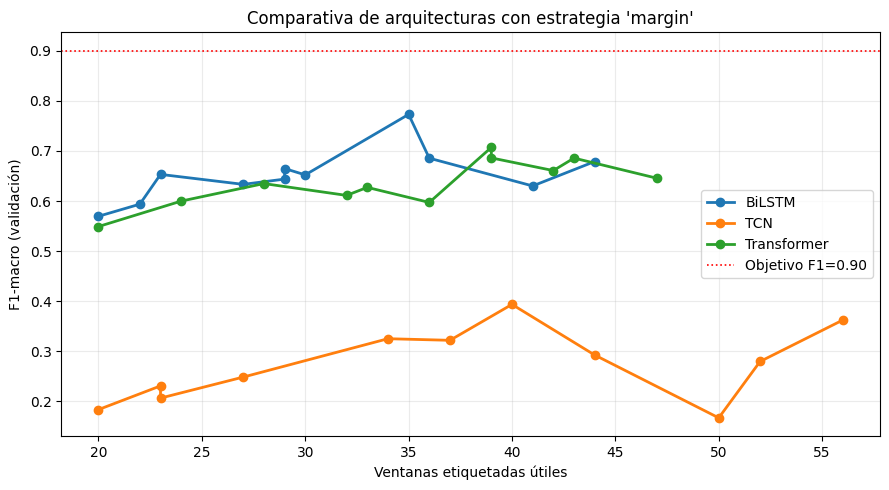

,Arquitectura,AULC,F1_final,N_para_F1_90,Consultas_desperdiciadas
0,Transformer,0.3623,0.6456,None,73
1,BiLSTM,0.3600,0.6788,None,76
2,TCN,0.1798,0.3624,None,64


Resultados guardados en results/phase5_arch_summary.csv


In [16]:
# Learning curves per architecture
plt.figure(figsize=(9, 5))
colors = {"BiLSTM": "#1f77b4", "TCN": "#ff7f0e", "Transformer": "#2ca02c"}

for arch_name, hist in arch_results.items():
    n_lab = np.array(hist["n_labeled"])
    f1s = np.array(hist["val_f1"])
    plt.plot(n_lab, f1s, marker="o", linewidth=2, label=arch_name, color=colors.get(arch_name, None))

plt.axhline(0.90, color="red", linestyle=":", linewidth=1.2, label="Objetivo F1=0.90")
plt.xlabel("Usefully labelled windows")
plt.ylabel("F1-macro (validation)")
plt.title(f"Architecture comparison, strategy '{best_strategy_name}'")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "phase5_arch_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla resumen arquitectura
rows_arch = []
for arch_name, hist in arch_results.items():
    n_lab = np.array(hist["n_labeled"])
    f1s = np.array(hist["val_f1"])
    aulc = float(_trapz(f1s, n_lab)) / max(n_lab.max(), 1)
    above_90 = n_lab[f1s >= 0.90]
    rows_arch.append({
        "Arquitectura": arch_name,
        "AULC": round(aulc, 4),
        "F1_final": round(float(f1s[-1]), 4),
        "N_para_F1_90": int(above_90.min()) if len(above_90) else None,
        "Consultas_desperdiciadas": int(sum(hist.get("wasted_queries", []))),
    })

df_arch = pd.DataFrame(rows_arch).sort_values("AULC", ascending=False).reset_index(drop=True)
display(df_arch)
df_arch.to_csv(PROJECT_ROOT / "results" / "phase5_arch_summary.csv", index=False)
print("Results saved to results/phase5_arch_summary.csv")


### Why the Transformer underperforms here

Transformers are more data-hungry: they need more examples to estimate attention
patterns without overfitting early. At these budgets, 20 to 120 useful labels, the
BiLSTM starts with an inductive bias suited to short, noisy time series, and that
shows up as stability and a better validation F1.

The conclusion is about this regime only. It says the BiLSTM is the right default
when labels are scarce, not that the architecture is better in general.

## §B4 Honest active learning: group split by held-out videos

This is the section that supersedes everything above.

The earlier protocol validated on a random split of windows from a single video.
With 75% overlap between consecutive windows, near-identical windows land on both
sides, and the "intelligent" strategies get credit for recognising windows they had
effectively already seen.

Here validation uses **whole held-out videos**, repeated over **5 seeds**, with a
**paired Wilcoxon test** against random.

**Verdict: no strategy beats random significantly**, all p > 0.05. The best,
`entropy`, shows a positive but inconclusive trend: ΔAULC +0.036, p = 0.063. Five
seeds do not have the power to confirm or rule out an effect that small.

Reproduces `results/al_honest_summary.csv` and `al_honest_runs.csv`.

In [ ]:
# Honest active learning: a group split by video, with whole videos held out, 5 seeds,
# and a paired Wilcoxon against random. Replaces the single-video random split, which
# leaked through the overlapping windows. Writes results/al_honest_{summary,runs}.csv.
import sys, pathlib, numpy as np, pandas as pd, torch, torch.nn as nn
import torch.utils.data as tud
from sklearn.model_selection import train_test_split
from scipy.stats import wilcoxon
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r / "src").exists():
    _r = _r.parent
if str(_r) not in sys.path:
    sys.path.insert(0, str(_r))
from src.evaluation.lovo import load_event_cache
from src.models.rnn import BehaviorGRU
from src.active_learning.query_strategies import (
    RandomStrategy, LeastConfidenceStrategy, MarginSamplingStrategy,
    EntropySamplingStrategy, CoresetStrategy, BADGEStrategy, run_al_cycle, aulc)

X, y, vids, classes = load_event_cache(
    _r / "dataset" / "features" / "CalMS21_task1_multi_20_event.npz")[:4]
nC, F = len(classes), X.shape[-1]
device = torch.device("cpu")
uniq = np.unique(vids)
SEEDS = [42, 123, 456, 7, 99]
EPOCHS, N_ROUNDS, N_QUERY, N_INIT = 15, 8, 20, 30
POOL_CAP, VAL_CAP = 2500, 900   # subsample WITHIN the group split (still leak-free) for CPU runtime
STRATS = ["random", "least_confidence", "margin", "entropy", "coreset", "badge"]

def make(name, seed):
    return {"random": RandomStrategy(seed=seed), "least_confidence": LeastConfidenceStrategy(),
            "margin": MarginSamplingStrategy(), "entropy": EntropySamplingStrategy(),
            "coreset": CoresetStrategy(), "badge": BADGEStrategy()}[name]

def model_factory():
    return BehaviorGRU(input_size=F, n_classes=nC)

def fit_fn(model, Xt, yt, vX, vY, dev):
    model = model.to(dev)
    c = np.bincount(yt, minlength=nC).astype(float); w = np.zeros(nC, np.float32); pos = c > 0
    w[pos] = c[pos].sum() / (pos.sum() * c[pos])
    crit = nn.CrossEntropyLoss(weight=torch.tensor(w).to(dev))
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    dl = tud.DataLoader(tud.TensorDataset(torch.tensor(Xt, dtype=torch.float32),
                                          torch.tensor(yt, dtype=torch.long)), batch_size=32, shuffle=True)
    model.train()
    for _ in range(EPOCHS):
        for xb, yb in dl:
            xb = torch.nan_to_num(xb.to(dev)); yb = yb.to(dev)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
    return model

rows = []
for seed in SEEDS:
    rng = np.random.RandomState(seed)
    val_vids = set(rng.permutation(uniq)[:max(1, round(0.2 * len(uniq)))])  # hold out whole videos
    vm = np.isin(vids, list(val_vids))
    vi = np.where(vm)[0]
    if len(vi) > VAL_CAP:
        vi = rng.choice(vi, VAL_CAP, replace=False)
    vX, vY = X[vi], y[vi]
    pa = np.where(~vm)[0]
    if len(pa) > POOL_CAP:
        pa = rng.choice(pa, POOL_CAP, replace=False)
    try:
        si, ui = train_test_split(pa, train_size=N_INIT, random_state=seed, stratify=y[pa])
    except ValueError:
        si, ui = train_test_split(pa, train_size=N_INIT, random_state=seed)
    for name in STRATS:
        torch.manual_seed(seed); np.random.seed(seed)
        h = run_al_cycle(make(name, seed), model_factory, X[si], y[si], X[ui], y[ui], vX, vY,
                         n_initial=N_INIT, n_query_per_round=N_QUERY, n_rounds=N_ROUNDS,
                         device=device, fit_fn=fit_fn, random_state=seed, verbose=False)
        rows.append({"strategy": name, "seed": seed,
                     "aulc": round(aulc(h["n_labeled"], h["val_f1"]), 4),
                     "final_f1": round(float(max(h["val_f1"])), 4)})

df = pd.DataFrame(rows)
piv = df.pivot(index="seed", columns="strategy", values="aulc")
r = piv["random"].values
summ = []
for name in STRATS:
    a = piv[name].values
    d = 0.0 if name == "random" else float((a - r).mean())
    if name == "random":
        pv = np.nan
    else:
        try:
            pv = float(wilcoxon(a, r).pvalue)
        except Exception:
            pv = np.nan
    summ.append({"strategy": name, "aulc_mean": round(a.mean(), 4), "aulc_std": round(a.std(), 4),
                 "delta_vs_random": round(d, 4), "wilcoxon_p": None if np.isnan(pv) else round(pv, 4),
                 "beats_random": bool(d > 0 and not np.isnan(pv) and pv < 0.05)})
sm = pd.DataFrame(summ).sort_values("aulc_mean", ascending=False)
df.to_csv(_r / "results" / "al_honest_runs.csv", index=False)
sm.to_csv(_r / "results" / "al_honest_summary.csv", index=False)
print("Honest AL - group split by video, 5 seeds, paired Wilcoxon vs random:")
print(sm.to_string(index=False))

Honest AL - group split by video, 5 seeds, paired Wilcoxon vs random:
        strategy  aulc_mean  aulc_std  delta_vs_random  wilcoxon_p  beats_random
         entropy     0.1738    0.0319           0.0356      0.0625         False
         coreset     0.1655    0.0288           0.0274      0.1875         False
          margin     0.1536    0.0210           0.0155      0.1250         False
least_confidence     0.1533    0.0161           0.0152      0.1875         False
           badge     0.1433    0.0095           0.0052      0.8125         False
          random     0.1381    0.0229           0.0000         NaN         False


## §A5 Does the skeleton correction help active learning?

Closes the raw-against-corrected comparison from notebooks 04 (§A3, shallow models)
and 05 (§A4, BiLSTM), now on the **active learning loop**.

Runs the loop with a `BehaviorGRU` over the paired caches, corrected against raw,
identical except for `smooth_video`, for two strategies, `random` as baseline and
`entropy` as the best acquirer, across several seeds.

The question is whether the correction shifts the **learning curve** upwards: more
F1 per label, a higher AULC. The delta in AULC and final F1 answers it.

  corrected | random   | seed=42 | AULC=0.3066 F1_final=0.3559
  corrected | entropy  | seed=42 | AULC=0.2883 F1_final=0.3541
  corrected | random   | seed=123 | AULC=0.3334 F1_final=0.2883
  corrected | entropy  | seed=123 | AULC=0.3449 F1_final=0.4342
  corrected | random   | seed=456 | AULC=0.3004 F1_final=0.3572
  corrected | entropy  | seed=456 | AULC=0.2788 F1_final=0.3643
  raw       | random   | seed=42 | AULC=0.3083 F1_final=0.3795
  raw       | entropy  | seed=42 | AULC=0.3225 F1_final=0.4183
  raw       | random   | seed=123 | AULC=0.3533 F1_final=0.3438
  raw       | entropy  | seed=123 | AULC=0.3892 F1_final=0.4362
  raw       | random   | seed=456 | AULC=0.3251 F1_final=0.3609
  raw       | entropy  | seed=456 | AULC=0.3524 F1_final=0.4632


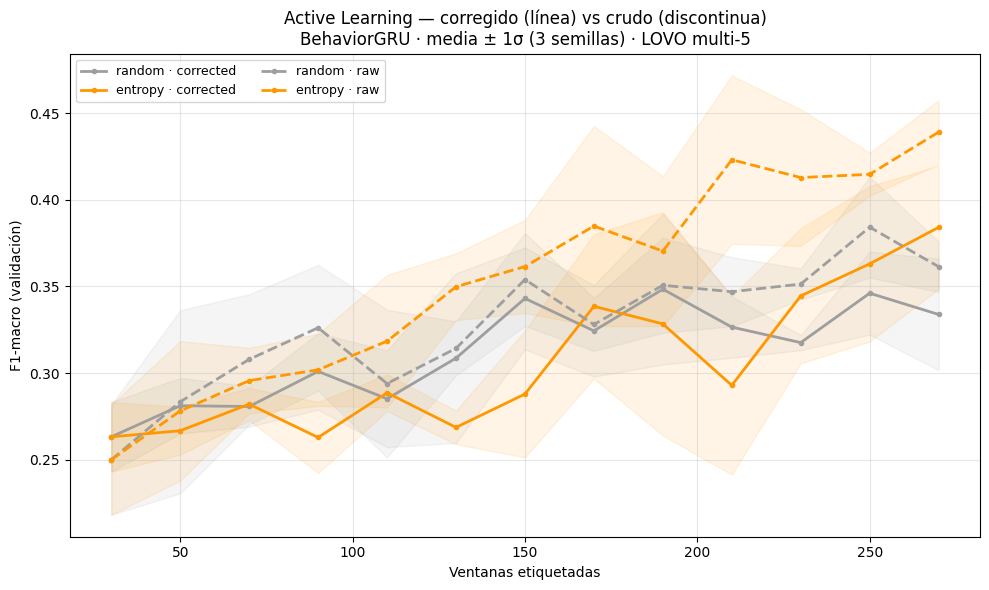


=== Efecto MouseSkeleton en AL (delta = corregido − crudo) ===
estrategia       AULC_corr        AULC_raw  AULC_delta      F1fin_corr       F1fin_raw  F1fin_delta
    random 0.3134 ± 0.0143 0.3289 ± 0.0186     -0.0155 0.3338 ± 0.0322 0.3614 ± 0.0146      -0.0276
   entropy 0.3040 ± 0.0292 0.3547 ± 0.0272     -0.0507 0.3842 ± 0.0356 0.4392 ± 0.0185      -0.0550

Guardado: c:\Users\User\dev\tfm\results\skeleton_effect_active_learning.csv
delta>0 => la corrección mejora la curva/objetivo de AL. Con 3 semillas y 5 vídeos es evidencia direccional.


In [18]:
# ── Effect of the MouseSkeleton correction on active learning ────────────────
# Does the AL learning curve improve with corrected features rather than raw ones?
# The two caches are paired and identical except for `smooth_video`.
# NOTE: the axis labels and title below stay in Spanish on purpose. The figure is
# used by the dissertation, which is not distributed here.
import sys, pathlib
_r = pathlib.Path.cwd()
while _r != _r.parent and not (_r/'src').exists(): _r = _r.parent
sys.path.insert(0, str(_r)) if str(_r) not in sys.path else None

import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from src.evaluation.lovo import load_event_cache
from src.models.rnn import BehaviorGRU
from src.active_learning.query_strategies import (
    RandomStrategy, EntropySamplingStrategy, aulc, run_al_cycle)

RESULTS_DIR = globals().get("RESULTS_DIR", _r / "results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FEAT = _r / "dataset" / "features"
CACHES = {"corrected": FEAT / "CalMS21_task1_multi_5_event.npz",
          "raw":       FEAT / "CalMS21_task1_multi_5_event_raw.npz"}
for _tag, _p in CACHES.items():
    if not _p.exists():
        raise FileNotFoundError(
            f"Cache {_tag} is missing: {_p.name}. Build the raw one with:\n"
            "  python -m scripts.build_event_cache --no-correct "
            "--out dataset/features/CalMS21_task1_multi_5_event_raw.npz")

AL_SEEDS   = [42, 123, 456]        # several seeds, for robustness
N_INITIAL  = 30
N_QUERY    = 20
N_ROUNDS   = 12
AL_EPOCHS  = 30
device_al  = torch.device("cpu")

def _make_pool(cache_path, seed):
    """Reproduce the pool/val split used by the AL-LOVO cell above."""
    X, y, vids, classes, _ = load_event_cache(cache_path)
    nC = len(classes)
    pool_idx, val_idx = train_test_split(np.arange(len(y)), test_size=0.2,
                                         random_state=seed, stratify=y)
    seed_idx, unlab_idx = train_test_split(pool_idx, train_size=N_INITIAL,
                                           random_state=seed, stratify=y[pool_idx])
    return (X[seed_idx], y[seed_idx], X[unlab_idx], y[unlab_idx],
            X[val_idx], y[val_idx], nC)

def _fit_al(model, Xt, yt, vX, vY, dev, nC):
    import torch.utils.data as tud
    model = model.to(dev)
    counts = np.bincount(yt, minlength=nC).astype(float)
    w = np.zeros(nC, np.float32); pr = counts > 0
    w[pr] = counts[pr].sum() / (pr.sum() * counts[pr])
    crit = nn.CrossEntropyLoss(weight=torch.tensor(w).to(dev))
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    dl = tud.DataLoader(tud.TensorDataset(torch.tensor(Xt, dtype=torch.float32),
                                          torch.tensor(yt, dtype=torch.long)),
                        batch_size=32, shuffle=True)
    model.train()
    for _ in range(AL_EPOCHS):
        for xb, yb in dl:
            xb = torch.nan_to_num(xb.to(dev)); yb = yb.to(dev)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
    return model

def _strategy(name, seed):
    return RandomStrategy(seed=seed) if name == "random" else EntropySamplingStrategy()

AL_STRATEGIES = ["random", "entropy"]     # the baseline plus the best acquirer
al_hist = {v: {s: [] for s in AL_STRATEGIES} for v in CACHES}   # variante -> strat -> [hist/seed]

for variant, cache_path in CACHES.items():
    for seed in AL_SEEDS:
        tr_X, tr_y, pl_X, pl_y, vX, vY, nC = _make_pool(cache_path, seed)
        F = tr_X.shape[-1]
        for sname in AL_STRATEGIES:
            torch.manual_seed(seed); np.random.seed(seed)
            h = run_al_cycle(
                _strategy(sname, seed),
                lambda: BehaviorGRU(input_size=F, n_classes=nC),
                tr_X, tr_y, pl_X, pl_y, vX, vY,
                n_initial=N_INITIAL, n_query_per_round=N_QUERY, n_rounds=N_ROUNDS,
                device=device_al,
                fit_fn=lambda m, Xt, yt, vx, vy, dev: _fit_al(m, Xt, yt, vx, vy, dev, nC),
                random_state=seed, verbose=False)
            al_hist[variant][sname].append(h)
            print(f"  {variant:9s} | {sname:8s} | seed={seed} | "
                  f"AULC={aulc(h['n_labeled'], h['val_f1']):.4f} "
                  f"F1_final={h['val_f1'][-1]:.4f}")

# ── Learning curves: corrected (solid) vs raw (dashed) ───────────────────────
def _agg(histories):
    lo = max(h["n_labeled"][0] for h in histories)
    hi = min(h["n_labeled"][-1] for h in histories)
    grid = np.linspace(lo, hi, N_ROUNDS + 1)
    F = np.array([np.interp(grid, h["n_labeled"], h["val_f1"]) for h in histories])
    return grid, F.mean(0), F.std(0)

_color = {"random": "#9E9E9E", "entropy": "#FF9800"}
fig, ax = plt.subplots(figsize=(10, 6))
for variant in CACHES:
    for sname in AL_STRATEGIES:
        g, mu, sd = _agg(al_hist[variant][sname])
        ls = "-" if variant == "corrected" else "--"
        ax.plot(g, mu, ls, color=_color[sname], marker="o", markersize=3, linewidth=2,
                label=f"{sname} · {variant}")
        ax.fill_between(g, mu - sd, mu + sd, color=_color[sname], alpha=0.10)
ax.set_xlabel("Ventanas etiquetadas"); ax.set_ylabel("F1-macro (validación)")
ax.set_title("Active Learning — corregido (línea) vs crudo (discontinua)\n"
             f"BehaviorGRU · media ± 1σ ({len(AL_SEEDS)} semillas) · LOVO multi-5")
ax.legend(fontsize=9, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "skeleton_effect_active_learning.png", dpi=150, bbox_inches="tight")
plt.show()

# ── AULC / F1_final table, with the delta (corrected minus raw) ──────────────
rows = []
for sname in AL_STRATEGIES:
    a_corr = [aulc(h["n_labeled"], h["val_f1"]) for h in al_hist["corrected"][sname]]
    a_raw  = [aulc(h["n_labeled"], h["val_f1"]) for h in al_hist["raw"][sname]]
    f_corr = [h["val_f1"][-1] for h in al_hist["corrected"][sname]]
    f_raw  = [h["val_f1"][-1] for h in al_hist["raw"][sname]]
    rows.append({
        "strategy": sname,
        "AULC_corr":   f"{np.mean(a_corr):.4f} ± {np.std(a_corr):.4f}",
        "AULC_raw":    f"{np.mean(a_raw):.4f} ± {np.std(a_raw):.4f}",
        "AULC_delta":  round(float(np.mean(a_corr) - np.mean(a_raw)), 4),
        "F1fin_corr":  f"{np.mean(f_corr):.4f} ± {np.std(f_corr):.4f}",
        "F1fin_raw":   f"{np.mean(f_raw):.4f} ± {np.std(f_raw):.4f}",
        "F1fin_delta": round(float(np.mean(f_corr) - np.mean(f_raw)), 4),
    })
df_al_skeleton = pd.DataFrame(rows)
print("\n=== Efecto MouseSkeleton en AL (delta = corregido − crudo) ===")
print(df_al_skeleton.to_string(index=False))
df_al_skeleton.to_csv(RESULTS_DIR / "skeleton_effect_active_learning.csv", index=False)
print("\nGuardado:", RESULTS_DIR / "skeleton_effect_active_learning.csv")
print("delta>0 means the correction improves the AL curve. With 3 seeds and "
      "5 videos this is directional evidence only.")

## Official MABe metric for the GRU under LOVO

The active learning loop validates on a random split, which is not comparable with
the challenge. This section evaluates the same GRU architecture with the **official
metric**, the interval F-beta, under leave-one-video-out, so this notebook also
reports `f1_event` on the same footing as 04 and 05.

Skips cleanly if the event cache is missing.

In [19]:
import numpy as np, pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from src.evaluation.lovo import load_event_cache, run_seq, event_f1_for_fold

Xe, ye, vidse, classes_e, ev = load_event_cache()
if ev is None:
    print("⚠ event cache has no per-window metadata; run: "
          "python -m scripts.build_event_cache")
else:
    LAB = "CalMS21_task1"; nCe = len(classes_e)
    ev_rows = []
    for fi, (tr, te) in enumerate(LeaveOneGroupOut().split(Xe, ye, groups=vidse)):
        pred, _ = run_seq("gru", Xe[tr], ye[tr], Xe[te], nCe, epochs=EPOCHS, device=device)
        fev = event_f1_for_fold(LAB, vidse[te][0], te, pred, classes_e, vidse, ev)
        ev_rows.append({"fold": fi, "test_video": vidse[te][0],
                        "f1_event": round(fev, 4) if not np.isnan(fev) else np.nan})
        print(f"  gru fold{fi} {vidse[te][0]:>10s}  f1_event={fev:.3f}")
    df_gru_event = pd.DataFrame(ev_rows)
    print()
    print(f"GRU LOVO f1_event: {df_gru_event.f1_event.mean():.3f} "
          f"± {df_gru_event.f1_event.std():.3f}")
    df_gru_event.to_csv(_r / "results" / "al_gru_event.csv", index=False)
    print("Saved:", _r / "results" / "al_gru_event.csv")

  gru fold0 1296577409  f1_event=0.254
  gru fold1   13638642  f1_event=0.123
  gru fold2  537514760  f1_event=0.334
  gru fold3  687327340  f1_event=0.766
  gru fold4  867864385  f1_event=0.770

GRU LOVO f1_event: 0.449 ± 0.300
Guardado: c:\Users\User\dev\tfm\results\al_gru_event.csv
